<a href="https://colab.research.google.com/github/zakari90/machine-learning/blob/main/reinforcement_learning_taxi_game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import gymnasium as gym

env = gym.make("Taxi-v4",render_mode="ansi")

env.reset(seed=0)

env = env.unwrapped

arr=env.render()
print(arr)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [5]:
print("Action Space ", env.action_space)
print("State Space ", env.observation_space)

Action Space  Discrete(6)
State Space  Discrete(500)


In [6]:

state = env.encode(3, 1, 2, 0)
print("State:", state)

env.s = state

arr=env.render()
print(arr)

State: 328
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [7]:
import numpy as np

states=env.observation_space.n
print(states)
actions=env.action_space.n
print(actions)
q_table = np.zeros([states, actions])
q_table

500
6


array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

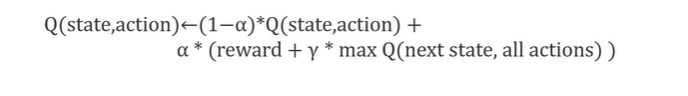

الصيغة الموجودة في الصورة هي معادلة تحديث Q-Learning، وهي المعادلة الأساسية التي يستخدمها وكيل التعلم المعزز (Reinforcement Learning) لتحديث معرفته بعد كل خطوة.

المعادلة هي:

Q(s,a)←(1−α)Q(s,a)+α(R+γ
a
′
max
Q(s
′
,a
′
))

حيث:

Q(s,a): القيمة الحالية لاتخاذ الإجراء a في الحالة s.
α (Learning Rate): معدل التعلم، ويحدد مقدار تأثير المعلومات الجديدة على القيمة القديمة.
قيمة كبيرة (مثل 0.9): يتعلم بسرعة.
قيمة صغيرة (مثل 0.1): يتعلم ببطء.
R (Reward): المكافأة التي حصل عليها الوكيل بعد تنفيذ الإجراء.
γ (Discount Factor): معامل الخصم، ويحدد مدى أهمية المكافآت المستقبلية.
إذا كان قريبًا من 0 → يهتم بالمكافأة الحالية فقط.
إذا كان قريبًا من 1 → يهتم بالمكافآت المستقبلية أيضًا.
maxQ(s
′
,a
′
): أفضل قيمة متوقعة يمكن الحصول عليها من الحالة التالية s
′
 باختيار أفضل إجراء ممكن.

In [ ]:

alpha = 0.4
gamma = 0.6
episodes = 100000

for i in range(episodes):

    state = env.reset()[0]
    epochs = 0
    penalties = 0
    done = False
    while not done:
        action = np.argmax(q_table[state])

        old_value = q_table[state, action]
        next_state, reward, done, _,_ = env.step(action)
        next_state=next_state
        next_max = np.max(q_table[next_state])

        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)

        q_table[state, action] = new_value

        state = next_state

print("Training finished.\n")